# Potts model: simulate, fit, search, learn

One pass through the repository's Potts instances, from a seeded fixture to a
learned search policy, with every claim checked against an oracle that shares
no code with what it checks.

**Scope.** Two instances, both taken from the fixture registry so that the
notebook and the regression suite run on the same problem: the **1-D chain in
an external field** (`potts_chain/ci`, sections 1-6) and the **2-D lattice**
(`potts_lattice/ci`, sections 7-10), which is the general Markov random field
`ROADMAP.md` §1.1 specifies, at the size an exact answer still reaches
(`snakes_and_ladders.sim.graph`, `snakes_and_ladders.sim.potts`; #190, closing
#170).

The model, for `q` states on a graph with edge set `E`:

$$P(s) \propto \exp\left(J \sum_{(i,j) \in E} \delta(s_i, s_j) + \sum_i h[s_i]\right)$$

with `J` a scalar coupling and `h` an external field. On the chain `E` is the
`L - 1` adjacent pairs, the graph is a tree, and the normalizer is exact by
transfer matrix — which is what makes every claim in sections 2-5 checkable.
On the lattice `E` is the 12 bonds of a 3x3 grid, whose four independent
cycles cost exactly that: section 8 measures what belief propagation gives up
where the chain gave up nothing.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from snakes_and_ladders.learn.policy import LinearPolicy
from snakes_and_ladders.learn.potts import (
    PottsLandscape,
    enumerate_configurations,
    optimum,
)
from snakes_and_ladders.learn.reinforce import reinforce
from snakes_and_ladders.learn.rollout import greedy_rollout, rollout
from snakes_and_ladders.likelihood.belief_propagation import belief_propagation
from snakes_and_ladders.likelihood.potts import enumerate_potts
from snakes_and_ladders.opt.fit import constrained_standard_errors, covers, fit
from snakes_and_ladders.opt.potts import (
    PottsLatticeObjective,
    PottsObjective,
    log_partition,
    simulate_chains,
)
from snakes_and_ladders.qa.style import notebook_style
from snakes_and_ladders.search.potts_mcmc import PottsMove, energies, sample_potts
from snakes_and_ladders.search.statistics import integrated_autocorrelation_time
from snakes_and_ladders.sim.fixtures import fixture
from snakes_and_ladders.sim.graph import lattice_graph
from snakes_and_ladders.sim.potts import simulate_potts

# The instance comes from the registry, which resolves the fixture files from
# the package rather than from wherever the notebook was opened.
params = fixture("potts_chain", "ci").params
print(f"states      {params.n_states}")
print(f"chain length {params.chain_length}")
print(f"chains      {params.n_chains}")
print(f"coupling J  {params.coupling}")
print(f"field h     {np.round(params.field, 4)}  (gauge: logsumexp(h) == 0)")
print(f"seed        {params.seed}")

states      3
chain length 12
chains      400
coupling J  0.75
field h     [-0.7434 -1.2434 -1.4434]  (gauge: logsumexp(h) == 0)
seed        20260902


## 1. Simulated data from a declared truth

The fixture states the truth; the simulator draws from it under a seeded
generator, so every number below reproduces from the yaml alone.

In [2]:
chains = simulate_chains(params)
print(f"simulated {chains.shape[0]} chains of length {chains.shape[1]}")
print("first three chains:")
print(chains[:3])

simulated 400 chains of length 12
first three chains:
[[2 0 0 0 0 0 2 2 0 0 0 0]
 [1 1 2 1 0 0 0 2 2 0 0 0]
 [0 0 1 1 1 2 0 1 1 0 0 0]]


## 2. The normalizer, against exhaustive enumeration

`log_partition` runs a transfer-matrix recursion in log space. Enumerating
every configuration sums the same quantity directly, sharing no code with it,
and costs `q**L` — which is why the check runs at `L = 6` and the fit does
not.

In [3]:
CHECK_LENGTH = 6
field = torch.as_tensor(params.field)
coupling = torch.tensor(params.coupling, dtype=torch.float64)

configurations = torch.tensor(
    list(enumerate_configurations(params.n_states, CHECK_LENGTH)), dtype=torch.long
)
agreements = (configurations[:, 1:] == configurations[:, :-1]).sum(dim=1)
enumerated_energies = coupling * agreements + field[configurations].sum(dim=1)

enumerated = torch.logsumexp(enumerated_energies, dim=0)
recursion = log_partition(coupling, field, CHECK_LENGTH)
deviation = abs(float(recursion - enumerated) / float(enumerated))
print(f"enumerated over {len(configurations)} configurations: {float(enumerated):.12f}")
print(f"transfer matrix:                        {float(recursion):.12f}")
print(f"relative deviation: {deviation:.2e}  (float64 epsilon 2.22e-16)")

enumerated over 729 configurations: 1.745790968912
transfer matrix:                        1.745790968912
relative deviation: 1.27e-16  (float64 epsilon 2.22e-16)


## 3. Fitting `J` and `h` by autodiff

`snakes_and_ladders.opt.fit` is model-agnostic: it sees an unconstrained parameter vector,
a differentiable scalar, and a map back to named constrained parameters. The
same call fits the hidden Markov model in `hmm.ipynb` and branch lengths in
`phylo_tree.ipynb`.

In [4]:
objective = PottsObjective(chains, params.n_states)
GRADIENT_TOLERANCE = 1e-8
result = fit(objective, gradient_tolerance=GRADIENT_TOLERANCE)
estimate = objective.constrain(result.theta)
error = constrained_standard_errors(objective, result.theta)

truth = torch.cat([coupling.reshape(1), field])
fitted = torch.cat([estimate["coupling"].reshape(1), estimate["field"]])
spread = torch.cat([error["coupling"].reshape(1), error["field"]])
hits = covers(fitted, spread, truth)

# The residual gradient norm is *not* printed. It is a near-zero number
# whose value is floating-point noise -- it moved from 6.5e-10 to 1.7e-10
# between two machines running this same cell, while every fitted
# parameter agreed to four decimals. `docs/CLAUDE.md` forbids the same
# thing in a generated caption for the same reason. What carries
# information is that the norm cleared the tolerance, so that is printed.
print(
    f"converged: {result.converged}, {result.iterations} L-BFGS steps, "
    f"relative gradient norm below {GRADIENT_TOLERANCE:.0e}\n"
)
print(f"{'parameter':<10}{'truth':>10}{'fitted':>10}{'std err':>10}   95% interval")
for name, true_value, point, deviation_, covered in zip(
    ["J", "h[0]", "h[1]", "h[2]"], truth, fitted, spread, hits, strict=True
):
    verdict = "covers" if bool(covered) else "MISSES"
    print(
        f"{name:<10}{float(true_value):>10.4f}{float(point):>10.4f}"
        f"{float(deviation_):>10.4f}   {verdict}"
    )
print(f"\n{int(hits.sum())} of {len(hits)} intervals cover their truth")

converged: True, 1 L-BFGS steps, relative gradient norm below 1e-08

parameter      truth    fitted   std err   95% interval
J             0.7500    0.7158    0.0327   covers
h[0]         -0.7434   -0.7439    0.0140   covers
h[1]         -1.2434   -1.2470    0.0201   covers
h[2]         -1.4434   -1.4380    0.0252   covers

4 of 4 intervals cover their truth


Coverage on one dataset is a draw, not a rate. The nominal 0.95 is checked
over independent replicates by the release-gated regression suite and plotted
in `docs/tex/figures/opt_coverage.pdf`, where the realized rate is 96/100 at
1600 chains.

## 4. Discrete search, where the answer is enumerable

Fitting is continuous; search is not. The landscape below is the same model
read as a search problem: a state is a configuration, an action is a
single-site flip, and the objective is the energy.

It runs at `L = 4` rather than the fixture's 12 because the claim being made
is *did the search find the best configuration*, and answering that needs all
`3**4 = 81` configurations enumerated. At `L = 12` there are 531,441.

In [5]:
SEARCH_LENGTH = 4
HORIZON = 6

landscape = PottsLandscape(params.coupling, params.field, SEARCH_LENGTH)
starts = list(enumerate_configurations(params.n_states, SEARCH_LENGTH))
best_configuration, best_energy = optimum(landscape)

print(f"{len(starts)} configurations enumerated")
print(f"global optimum {best_configuration} at energy {best_energy:.4f}")
print(f"actions per state: {len(landscape.actions(starts[0]))}")

81 configurations enumerated
global optimum (0, 0, 0, 0) at energy -0.7237
actions per state: 8


In [6]:
greedy_finals = [
    landscape.energy(greedy_rollout(landscape, start, HORIZON).states[-1])
    for start in starts
]
greedy_hits = np.mean([abs(value - best_energy) < 1e-9 for value in greedy_finals])
print(f"hill climbing from all {len(starts)} starts, {HORIZON} steps each")
print(f"  mean final energy {np.mean(greedy_finals):.4f}  (optimum {best_energy:.4f})")
print(f"  reached the optimum from {greedy_hits:.1%} of starts")

hill climbing from all 81 starts, 6 steps each
  mean final energy -1.1780  (optimum -0.7237)
  reached the optimum from 80.2% of starts


## 5. Training data, and a learned policy

Hill climbing leaves 19.8% of starts short. The policy scores each available
flip by two features — the change in agreement and the change in field — and
samples from a softmax over those scores. Training data is the episodes it
rolls out: `iterations x batch` of them, each `HORIZON` steps.

Hill climbing is *inside* this policy class, at the weight vector
proportional to `(J, 1)`, so beating it is a statement about learning rather
than about two unrelated algorithms.

In [7]:
ITERATIONS, BATCH = 60, 32

policy = LinearPolicy(landscape.n_features())
training = reinforce(
    landscape,
    policy,
    np.random.default_rng(0),
    iterations=ITERATIONS,
    batch=BATCH,
    max_steps=HORIZON,
)
print(f"{training.episodes} episodes sampled over {ITERATIONS} iterations")
print(f"learned weights {policy.weights.detach().numpy().round(4)}")
print(f"greedy weights  {landscape.greedy_weights().numpy()}")

1920 episodes sampled over 60 iterations
learned weights [0.9103 2.4172]
greedy weights  [0.75 1.  ]


In [8]:
ROLLOUTS_PER_START = 16

rng = np.random.default_rng(3)
learned_finals = [
    landscape.energy(rollout(landscape, policy, rng, HORIZON, start=start).states[-1])
    for start in starts
    for _ in range(ROLLOUTS_PER_START)
]
learned_hits = np.mean([abs(value - best_energy) < 1e-9 for value in learned_finals])

print(f"{'':<18}{'mean final E':>14}{'reached optimum':>18}")
print(f"{'hill climbing':<18}{np.mean(greedy_finals):>14.4f}{greedy_hits:>17.1%}")
print(f"{'learned policy':<18}{np.mean(learned_finals):>14.4f}{learned_hits:>17.1%}")
print(f"{'enumerated optimum':<18}{best_energy:>14.4f}{1.0:>17.1%}")

                    mean final E   reached optimum
hill climbing            -1.1780            80.2%
learned policy           -0.9965            87.0%
enumerated optimum       -0.7237           100.0%


The sampled return the training loop reports is a diagnostic, not the result:
it is a Monte Carlo estimate under a changing policy, and a score-function
estimator with a sign error rises too. The result is the comparison above,
against exhaustive enumeration.

## 6. Energy against step within an episode

What the two searchers do, step by step, against the enumerated optimum.

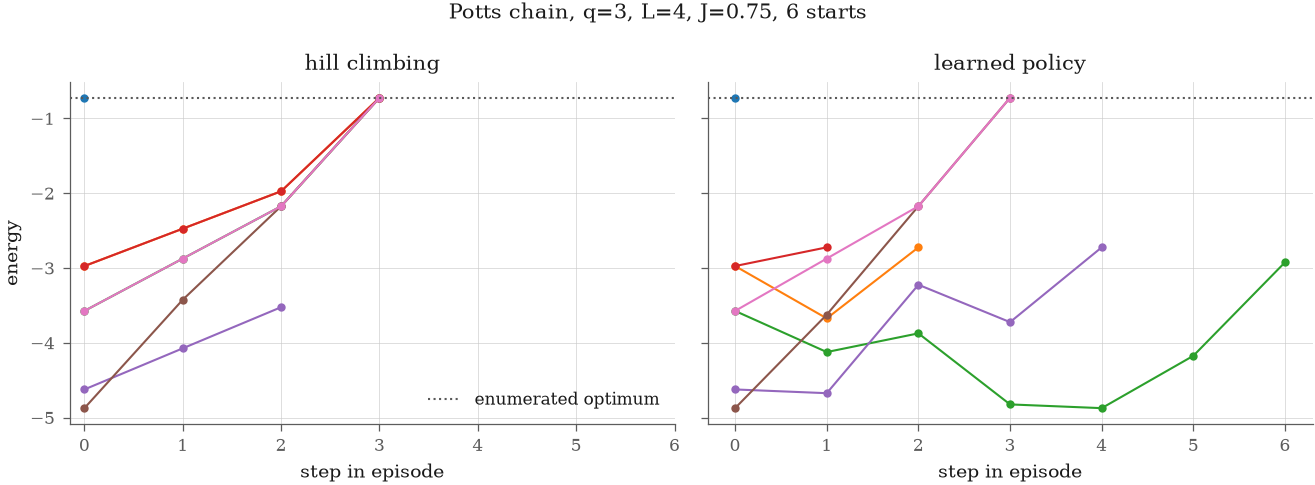

In [9]:
with notebook_style():
    PROBE_STARTS = 6

    figure, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), sharey=True)
    probe_rng = np.random.default_rng(11)
    probes = [
        starts[index] for index in range(0, len(starts), len(starts) // PROBE_STARTS)
    ]

    for axis, label, episodes in (
        (
            axes[0],
            "hill climbing",
            [greedy_rollout(landscape, start, HORIZON) for start in probes],
        ),
        (
            axes[1],
            "learned policy",
            [
                rollout(landscape, policy, probe_rng, HORIZON, start=start)
                for start in probes
            ],
        ),
    ):
        for episode in episodes:
            trace = [landscape.energy(state) for state in episode.states]
            axis.plot(range(len(trace)), trace, marker="o", markersize=3, linewidth=1.0)
        axis.axhline(
            best_energy,
            color="0.35",
            linestyle=":",
            linewidth=1.0,
            label="enumerated optimum",
        )
        axis.set_title(label, fontsize=10)
        axis.set_xlabel("step in episode")
        axis.set_xticks(range(HORIZON + 1))
    axes[0].set_ylabel("energy")
    axes[0].legend(fontsize=8, loc="lower right")
    figure.suptitle(
        f"Potts chain, q={params.n_states}, L={SEARCH_LENGTH}, J={params.coupling}, "
        f"{PROBE_STARTS} starts",
        fontsize=10,
    )
    figure.tight_layout()
    plt.show()

## 7. The lattice, and the cycles that come with it

Sections 1-6 are the chain. The same model on a 3x3 grid differs in one
respect that decides everything below: the graph has cycles. `potts_lattice/ci`
is the instance the regression suite runs on — the simulator's validation
draw, the belief-propagation deviation and the lattice fit all read this file
— so the numbers here are the numbers it pins.

In [10]:
lattice = fixture("potts_lattice", "ci")
instance = lattice.params
graph = lattice_graph(instance.shape, instance.boundary, instance.coupling)

# `h` and `h + c` are the same model. The chain loader canonicalizes to
# logsumexp(h) == 0 and the lattice loader leaves the file's gauge alone, so
# it is fixed here: the objective in section 10 is parameterized in that
# gauge, and a truth stated in another one is a different number rather than
# a different convention.
lattice_field = instance.field - math.log(float(np.exp(instance.field).sum()))

print(f"fixture      {lattice.problem}/{lattice.tier}, oracle {lattice.oracle}")
print(f"shape        {instance.shape}, {instance.boundary} boundary")
print(f"sites        {graph.n_nodes}, edges {len(graph.edges)}")
print(f"cycle rank   {len(graph.edges) - graph.n_nodes + 1}  (a chain's is 0)")
print(
    f"states       {instance.n_states}, configurations {instance.n_states**graph.n_nodes}"
)
print(f"coupling J   {instance.coupling}")
print(f"field h      {np.round(lattice_field, 4)}  (gauge: logsumexp(h) == 0)")

fixture      potts_lattice/ci, oracle enumeration
shape        (3, 3), open boundary
sites        9, edges 12
cycle rank   4  (a chain's is 0)
states       3, configurations 19683
coupling J   0.6
field h      [-0.8228 -1.2228 -1.3228]  (gauge: logsumexp(h) == 0)


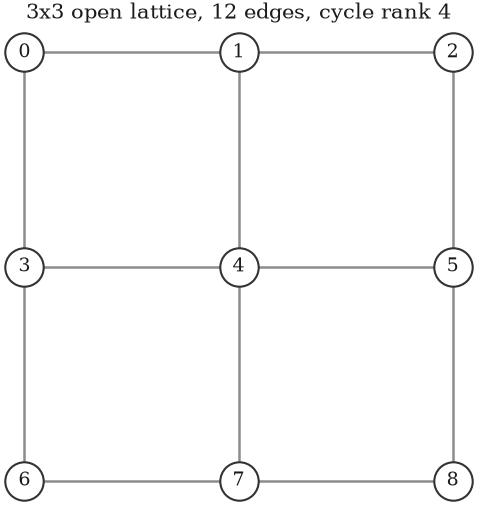

In [11]:
with notebook_style():
    rows, columns = instance.shape
    coordinates = {}
    for node in range(graph.n_nodes):
        row, column = np.unravel_index(node, instance.shape)
        coordinates[node] = (float(column), float(rows - 1 - row))

    figure, axis = plt.subplots(figsize=(3.6, 3.6))
    for first, second in graph.edges:
        start, end = coordinates[first], coordinates[second]
        axis.plot(
            [start[0], end[0]],
            [start[1], end[1]],
            color="0.55",
            linewidth=1.2,
            zorder=1,
        )
    axis.scatter(
        [point[0] for point in coordinates.values()],
        [point[1] for point in coordinates.values()],
        s=340,
        color="white",
        edgecolor="0.2",
        zorder=2,
    )
    for node, (x, y) in coordinates.items():
        axis.text(x, y, str(node), ha="center", va="center", fontsize=9, zorder=3)
    axis.set_title(
        f"{rows}x{columns} {instance.boundary} lattice, {len(graph.edges)} edges, "
        f"cycle rank {len(graph.edges) - graph.n_nodes + 1}",
        fontsize=10,
    )
    axis.set_aspect("equal")
    axis.set_axis_off()
    figure.tight_layout()
    plt.show()

## 8. The normalizer on a loopy graph: Bethe against enumeration

Section 2 checked the chain's transfer matrix against enumeration and found
them equal to 1.3e-16: a tree carries no cycle and the recursion is exact.
Belief propagation is that same message passing on a graph where a message
eventually depends on itself, so on this lattice it is an approximation and
the Bethe free energy is an estimate of `log Z` rather than `log Z`. What is
reported is therefore how large the error is, not that there is none.

Enumeration over all 19,683 configurations is the referee, and it is the
referee at this size and no larger — a 4x4 lattice is 43 million.
`tests/regression/likelihood/test_belief_propagation.py::test_the_bethe_deviation_on_the_registry_lattice_is_the_measured_size`
pins the three deviations printed below. In the same file,
`test_a_zero_coupling_lattice_is_exact_despite_its_loops` separates *loopy*
from *approximate* — the cycles stay, the coupling goes, and exactness comes
back — and `test_the_bethe_deviation_is_the_measured_size` follows the error
across the coupling, where it peaks near the transition rather than growing
without bound.

In [12]:
exact = enumerate_potts(graph, lattice_field)
bethe = belief_propagation(graph, lattice_field)

absolute = abs(bethe.bethe_log_partition - exact.log_partition)
relative = absolute / abs(exact.log_partition)
marginal = float(np.abs(bethe.single_site - exact.single_site).max())

# The sweep count belief propagation converged in is *not* printed, for the
# reason section 3 does not print a residual gradient norm: it is a threshold
# crossing on a float residual, and a machine summing the messages in another
# order lands a sweep either side of it while every deviation below agrees.
print(
    f"enumerated over {instance.n_states**graph.n_nodes} configurations: {exact.log_partition:.9f}"
)
print(f"Bethe approximation:                          {bethe.bethe_log_partition:.9f}")
print(f"  deviation in log Z   {absolute:.2e} absolute, {relative:.2e} relative")
print(f"  largest deviation in a single-site marginal  {marginal:.2e}")

enumerated over 19683 configurations: 3.147908296
Bethe approximation:                          3.133197814
  deviation in log Z   1.47e-02 absolute, 4.67e-03 relative
  largest deviation in a single-site marginal  4.25e-03


## 9. Move sets: single-site flips against Swendsen-Wang and Wolff

All three move sets leave the same Boltzmann distribution invariant, which
`tests/regression/search/test_potts_mcmc.py::test_the_chain_is_drawn_from_the_exact_boltzmann_distribution`
asserts by chi-square against enumeration for each of them. They differ in
how fast a chain forgets where it started, and that is what the integrated
autocorrelation time of the energy measures.

Two normalizations, because a sweep is not the same work for all three. A
single-site sweep and a Swendsen-Wang sweep touch every site; a Wolff sweep
flips one cluster. `tau` in sweeps is what an equal-sweep budget buys, and
`tau` in site updates is that scaled by the sites a sweep actually touched,
which is what an equal-work budget buys.

In [13]:
SWEEPS = 4_000


def autocorrelation(graph, field, move, n_sweeps, seed=7):
    """Energy autocorrelation time in sweeps, sites per sweep, and tau per site update."""
    chain = sample_potts(
        graph, field, move, np.random.default_rng(seed), n_sweeps, burn_in=n_sweeps // 5
    )
    tau = integrated_autocorrelation_time(energies(graph, field, chain.states))
    return tau, chain.mean_cluster_size, tau * chain.mean_cluster_size / graph.n_nodes


COLUMNS = (
    f"{'move':<16}{'sweeps':>8}{'sites per sweep':>17}"
    f"{'tau (sweeps)':>14}{'tau (site updates)':>20}"
)

print(
    f"{instance.shape[0]}x{instance.shape[1]} registry lattice at J = {instance.coupling}"
)
print(COLUMNS)
for move in PottsMove:
    tau, cluster, per_site = autocorrelation(graph, lattice_field, move, SWEEPS)
    print(f"{move.value:<16}{SWEEPS:>8}{cluster:>17.2f}{tau:>14.2f}{per_site:>20.2f}")

3x3 registry lattice at J = 0.6
move              sweeps  sites per sweep  tau (sweeps)  tau (site updates)


single-site         4000             9.00          1.00                1.00


swendsen-wang       4000             9.00          1.71                1.71
wolff               4000             2.09          6.84                1.59


The cluster moves are *behind* single-site flips here, on both
normalizations, and that is the instance rather than the algorithm. The
registry lattice is 9 sites at `J = 0.6`, and the exact 3-state transition on
a square lattice is at `J_c = ln(1 + sqrt(3)) = 1.005`: below it, on a
lattice shorter than the correlation length, there is no critical slowing for
a cluster to remove and the bonds it builds are paid for nothing. The three
times above are pinned by
`tests/regression/search/test_potts_mcmc.py::test_the_cluster_advantage_is_absent_at_the_registry_instance`.

Where the cluster updates earn their name is at the transition, on a lattice
large enough to slow down.
`tests/regression/search/test_potts_mcmc.py::test_cluster_updates_decorrelate_faster_at_the_transition`
measures them there and asserts the ordering; the cell below runs its
configuration — a 12x12 open lattice at `J_c` in zero field, at the sweep
counts that give the three chains comparable work. No fixture declares that
lattice, which is a Further Work bullet rather than an oversight.

In [14]:
TRANSITION = math.log(1.0 + math.sqrt(3.0))
critical = lattice_graph((12, 12), instance.boundary, TRANSITION)

print(
    f"12x12 {instance.boundary} lattice at J_c = ln(1 + sqrt(3)) = {TRANSITION:.4f}, zero field"
)
print(COLUMNS)
for move in PottsMove:
    n_sweeps = 12_000 if move is PottsMove.WOLFF else 1_500
    tau, cluster, per_site = autocorrelation(
        critical, np.zeros(instance.n_states), move, n_sweeps
    )
    print(f"{move.value:<16}{n_sweeps:>8}{cluster:>17.2f}{tau:>14.2f}{per_site:>20.2f}")

12x12 open lattice at J_c = ln(1 + sqrt(3)) = 1.0051, zero field
move              sweeps  sites per sweep  tau (sweeps)  tau (site updates)


single-site         1500           144.00          6.70                6.70


swendsen-wang       1500           144.00          4.17                4.17


wolff              12000            25.20         13.36                2.34


## 10. Fitting the lattice coupling and field

The `snakes_and_ladders.opt.fit` call section 3 makes for the chain, against a
different objective and otherwise unchanged: `PottsLatticeObjective`
normalizes by enumerating all 19,683 configurations, so the gradient it hands
the optimizer is exact rather than sampled, and a fitted optimum can be
checked against a brute-force scan of the objective instead of against the
optimizer's own convergence — which
`tests/regression/opt/test_opt_potts_lattice.py::test_the_fitted_optimum_beats_a_brute_force_scan`
does.

The draw is the suite's rather than the fixture's own 2,000-configuration
validation draw, so that the coverage printed here is coverage a test
asserts: 400 configurations at seed 20260904, each its own 200-sweep Gibbs
chain, which is what
`test_the_couplings_and_fields_are_recovered_within_their_intervals` fits.
Coverage on one dataset is a draw and not a rate; the rate over 40 replicates
is 153/160 at this size, release-gated in the same file.

In [15]:
DRAW_SEED, DRAWS, LATTICE_BURN_IN = 20260904, 400, 200

drawn = simulate_potts(
    graph,
    lattice_field,
    rng=np.random.default_rng(DRAW_SEED),
    n_samples=DRAWS,
    burn_in=LATTICE_BURN_IN,
)
lattice_objective = PottsLatticeObjective(
    drawn.configurations, instance.n_states, graph.edges
)
lattice_result = fit(lattice_objective)
lattice_estimate = lattice_objective.constrain(lattice_result.theta)
lattice_error = constrained_standard_errors(lattice_objective, lattice_result.theta)

lattice_truth = torch.cat(
    [
        torch.tensor([instance.coupling], dtype=torch.float64),
        torch.as_tensor(lattice_field),
    ]
)
lattice_fitted = torch.cat(
    [lattice_estimate["coupling"].reshape(1), lattice_estimate["field"]]
)
lattice_spread = torch.cat(
    [lattice_error["coupling"].reshape(1), lattice_error["field"]]
)
lattice_hits = covers(lattice_fitted, lattice_spread, lattice_truth)

print(
    f"{DRAWS} configurations, each a {LATTICE_BURN_IN}-sweep Gibbs chain; "
    f"converged: {lattice_result.converged}\n"
)
print(f"{'parameter':<10}{'truth':>10}{'fitted':>10}{'std err':>10}   95% interval")
for name, true_value, point, deviation, covered in zip(
    ["J", "h[0]", "h[1]", "h[2]"],
    lattice_truth,
    lattice_fitted,
    lattice_spread,
    lattice_hits,
    strict=True,
):
    verdict = "covers" if bool(covered) else "MISSES"
    print(
        f"{name:<10}{float(true_value):>10.4f}{float(point):>10.4f}"
        f"{float(deviation):>10.4f}   {verdict}"
    )
print(f"\n{int(lattice_hits.sum())} of {len(lattice_hits)} intervals cover their truth")

400 configurations, each a 200-sweep Gibbs chain; converged: True

parameter      truth    fitted   std err   95% interval
J             0.6000    0.6133    0.0275   covers
h[0]         -0.8228   -0.8504    0.0159   covers
h[1]         -1.2228   -1.2205    0.0211   covers
h[2]         -1.3228   -1.2813    0.0232   covers

4 of 4 intervals cover their truth


## Further work

What this notebook does not demonstrate. Each line names the issue that
carries it, and whether the gap is capability or coverage.

- **A lattice at the transition (#413), and the other lattice types (#231).**
  The registry carries one lattice: a 3x3 open square at `J = 0.6`, below
  `J_c`. Section 9's critical comparison therefore runs on a 12x12 lattice the
  cell builds as the regression suite builds it, not on a declared instance,
  which is #413; the periodic boundaries, the triangular lattice and the
  `G(n, p)` graphs `snakes_and_ladders.sim.graph` already draws appear nowhere
  here, which is #231. Both gaps are coverage rather than capability.
- **The lattice past the size enumeration reaches (#405).** Sections 8 and 10
  both rest on summing all `3**9 = 19,683` configurations, and a 4x4 lattice
  is 43 million. What the Bethe deviation and the fit cost, and what they are
  worth where no exact referee exists, is not shown; #405 carries the
  efficiency and scaling assessment.
- **Discrete search on the lattice (#226).** Sections 4 and 5 search the
  chain; the lattice is sampled and fitted and nothing here minimizes its
  energy. `snakes_and_ladders.search.alpha_expansion.iterated_conditional_modes`
  and `alpha_expansion` exist, so the gap is coverage, and #226 carries
  making iterated conditional modes a first-class solver across every lattice
  model.
- **A learned policy on the lattice (#414).** Section 5's policy is the
  chain's, over single-site flips at `L = 4`. The lattice's policy is a weight
  transfer across sizes, which `TICKETS.md` carries under curriculum learning:
  the surrogates transfer from 3x3 to 4x6 lattices and a policy does not yet.